# Brazil-Real-Estate-EDA

## Project Objectives:
To answer the question **Are property prices in Mexico more influenced by property size or by location?**

## Technical stack:
* **Data Manipulation:** `NumPy`, `Pandas`\
* **Data Visulaizatio:** `Matplotlib`, `Seaborn`


## Summary Statistics

In [25]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [26]:
# Define the path to the first file
path_1 = "./Data/brasil-real-estate-1.csv"

# Load the dataset
df1 = pd.read_csv(path_1)

### Inspecting the data: Five-Method Ritual

In [27]:
# Get the head of the dataframe
df1.head(10)

,property_type,place_with_parent_names,region,lat-lon,area_m2,price_usd
0,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6443051,-35.7088142",110.0,"$187,230.85"
1,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6430934,-35.70484",65.0,"$81,133.37"
2,house,|Brasil|Alagoas|Maceió|,Northeast,"-9.6227033,-35.7297953",211.0,"$154,465.45"
3,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.622837,-35.719556",99.0,"$146,013.20"
4,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.654955,-35.700227",55.0,"$101,416.71"
5,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.614414,-35.735621",56.0,"$75,727.07"
6,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.584755,-35.662909",68.0,"$110,916.18"
7,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.658285,-35.703827",187.0,"$249,641.14"
8,apartment,|Brasil|Alagoas|Maceió|,Northeast,NaN,65.0,"$100,792.61"
9,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.66082,-35.702976",90.0,"$115,459.02"


**Observations:**
* "place_with_parent_names" has more than one info. 
* lat-lon combines two columns.
* price_usd has $ symbol in the entries.

In [28]:
# Get the shape of the dataframe
df1.shape

(12834, 6)

In [29]:
# Get the info
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 12834 entries, 0 to 12833
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   property_type            12834 non-null  str    
 1   place_with_parent_names  12834 non-null  str    
 2   region                   12834 non-null  str    
 3   lat-lon                  11551 non-null  str    
 4   area_m2                  12834 non-null  float64
 5   price_usd                12834 non-null  str    
dtypes: float64(1), str(5)
memory usage: 601.7 KB


**Observations:**
* lat-lon is str.
* price_usd is str.

In [30]:
# Reveal the types 
df1.dtypes

property_type                  str
place_with_parent_names        str
region                         str
lat-lon                        str
area_m2                    float64
price_usd                      str
dtype: object

In [31]:
# Missing entries
df1.isnull().sum()

property_type                 0
place_with_parent_names       0
region                        0
lat-lon                    1283
area_m2                       0
price_usd                     0
dtype: int64

**Observations:**
- lat-lon is missing 1283 entries.

Before doing anything with the missing entries, let's explore whether they are clustered or not.

<Axes: >

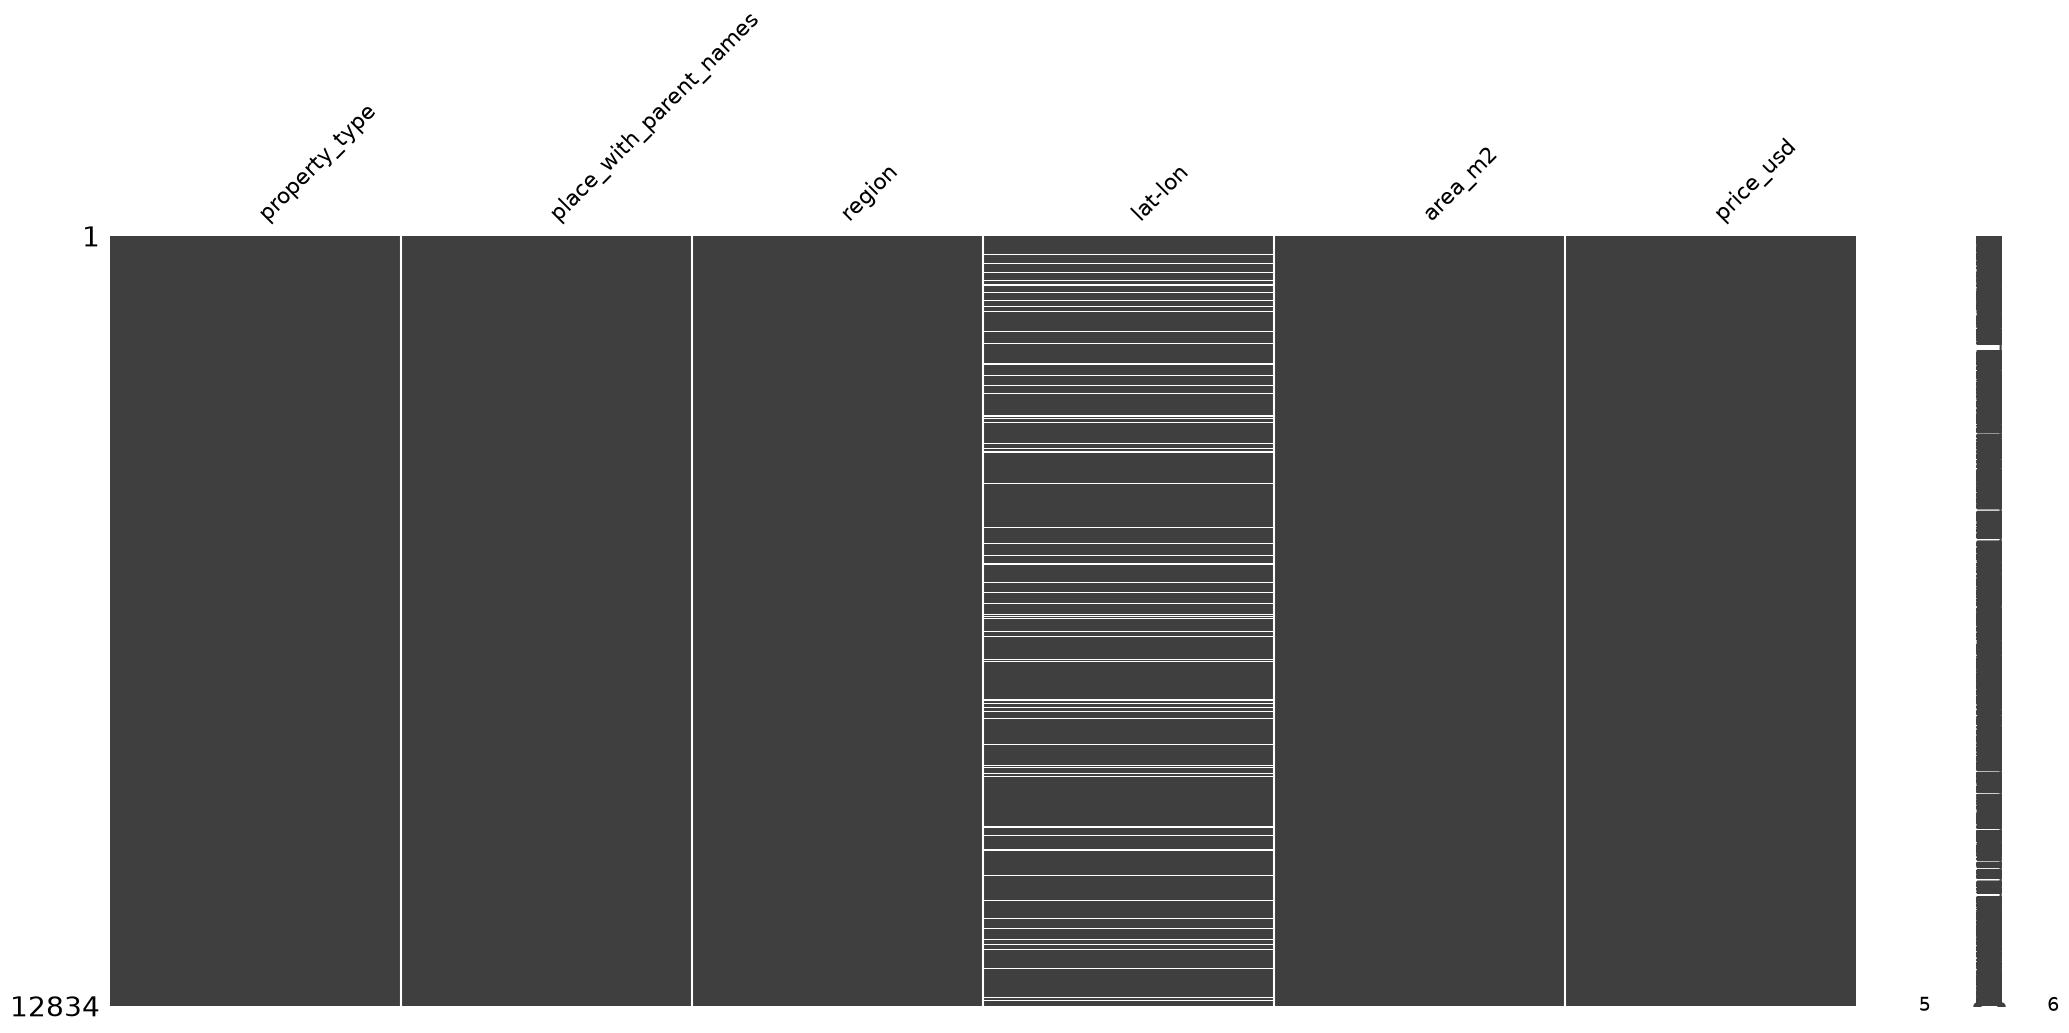

In [32]:
# Draw a matrix plot to visualize cluster
msno.matrix(df1)

**Observations:** 
* Nope, they aren't clustered.

In [33]:
# Calculate the percentag of missing entries
pct_missing_entries = (df1.isnull().sum().sum() / len(df1)) * 100
print(f"Percentage of missing entries: {pct_missing_entries:.2f}%")

Percentage of missing entries: 10.00%


Since, missing entries are just 10%, it is perfectly ok remove the observations containing those missing values. 

In [ ]:
df1_clean = (
    # Copy the dataframe
    df1.copy()      # saves time
    # Drop the missing rows
    .dropna(ignore_index=True)              # ignore_index=True resets the indexes

    # Modify "price_usd" and create "lon", "lat", "state" variables
    .assign(
        # Modify "price_usd" variable
        price_usd = lambda x: x["price_usd"]
                                .str.replace("$", "",  regex=False)       # .str was used because x["price_usd"] is a pandas series rather than a single text
                                .str.replace(",", "", regex=False)
                                .astype(float),
        # Create "lat" and split "lat-lon"
        lat = lambda x: x["lat-lon"]
                        .str.split(",", expand=True)[0]
                        .astype(float),

        # Create "lon" and split "lat-lon"
        lon = lambda x: x["lat-lon"]
                        .str.split(",", expand=True)[1]
                        .astype(float),
        # Create "state" variable
        state = lambda x: x["place_with_parent_names"]
                        .str.split("|", expand=True)[1]
                        .astype(str)
    )
    # Drop the unnecessary variables
    .drop(columns=["place_with_parent_names", "lat-lon"])
)


In [ ]:
# Check the dataframe with head
df1_clean.head()

,property_type,region,area_m2,price_usd,lat,lon,state
0,apartment,Northeast,110.0,187230.85,-9.644305,-35.708814,Brasil
1,apartment,Northeast,65.0,81133.37,-9.643093,-35.704840,Brasil
2,house,Northeast,211.0,154465.45,-9.622703,-35.729795,Brasil
3,apartment,Northeast,99.0,146013.20,-9.622837,-35.719556,Brasil
4,apartment,Northeast,55.0,101416.71,-9.654955,-35.700227,Brasil


In [42]:
# Check the dataframe with info
df1_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 11551 entries, 0 to 11550
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  11551 non-null  str    
 1   region         11551 non-null  str    
 2   area_m2        11551 non-null  float64
 3   price_usd      11551 non-null  float64
 4   lat            11551 non-null  float64
 5   lon            11551 non-null  float64
 6   state          11551 non-null  str    
dtypes: float64(4), str(3)
memory usage: 631.8 KB


In [ ]:
# Define the path for 2nd dataframe
path_2 = "./Data/brasil-real-estate-2.csv"

# Read the csv file
df2 = pd.read_csv(path_2)

# Inspecting the 2nd dataframe with head
df2.head()

,property_type,state,region,lat,lon,area_m2,price_brl
0,apartment,Pernambuco,Northeast,-8.134204,-34.906326,72.0,414222.98
1,apartment,Pernambuco,Northeast,-8.126664,-34.903924,136.0,848408.53
2,apartment,Pernambuco,Northeast,-8.125550,-34.907601,75.0,299438.28
3,apartment,Pernambuco,Northeast,-8.120249,-34.895920,187.0,848408.53
4,apartment,Pernambuco,Northeast,-8.142666,-34.906906,80.0,464129.36


**Observations:** 
* Price is in brl instead of usd.

In [45]:
# Inspect the 2nd dataframe with shape
df2.shape

(12833, 7)

In [46]:
# Inspect the 2nd dataframe with info
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 12833 entries, 0 to 12832
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  12833 non-null  str    
 1   state          12833 non-null  str    
 2   region         12833 non-null  str    
 3   lat            12833 non-null  float64
 4   lon            12833 non-null  float64
 5   area_m2        11293 non-null  float64
 6   price_brl      12833 non-null  float64
dtypes: float64(4), str(3)
memory usage: 701.9 KB


In [52]:
# Inspect the 2nd datafrme with isnull()
df2.isnull().sum()

property_type       0
state               0
region              0
lat                 0
lon                 0
area_m2          1540
price_brl           0
dtype: int64

In [57]:
# Calculate the percentage of missing entries
pct_missing_entries_2 = (df2.isnull().sum().sum() / len(df2)) * 100
print(f"Percentage of missing entries in the second dataframe: {pct_missing_entries_2:.2f}%")

Percentage of missing entries in the second dataframe: 12.00%


### Since this value is about 12%, we can simply remove those rows containing the missing values.

In [ ]:
# Define the brl to usd rate
brl_to_usd_rate = 0.19

df2_clean = (
                # Copy the 2nd dataframe
                df2.copy()

                # Create the price_usd variable from price_brl
                .assign(
                    price_usd = lambda x: x["price_brl"] * brl_to_usd_rate
                )
                # Drop the price_brl column
                .drop(columns=["price_brl"])

                # Remove the rows containing NaN 
                .dropna()
)

In [68]:
# Inspect the 2nd dataframe with head
df2_clean.head()

,property_type,state,region,lat,lon,area_m2,price_usd
0,apartment,Pernambuco,Northeast,-8.134204,-34.906326,72.0,78702.3662
1,apartment,Pernambuco,Northeast,-8.126664,-34.903924,136.0,161197.6207
2,apartment,Pernambuco,Northeast,-8.125550,-34.907601,75.0,56893.2732
3,apartment,Pernambuco,Northeast,-8.120249,-34.895920,187.0,161197.6207
4,apartment,Pernambuco,Northeast,-8.142666,-34.906906,80.0,88184.5784


In [69]:
# Inspect the 2nd dataframe with info
df2_clean.info()

<class 'pandas.DataFrame'>
Index: 11293 entries, 0 to 12832
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  11293 non-null  str    
 1   state          11293 non-null  str    
 2   region         11293 non-null  str    
 3   lat            11293 non-null  float64
 4   lon            11293 non-null  float64
 5   area_m2        11293 non-null  float64
 6   price_usd      11293 non-null  float64
dtypes: float64(4), str(3)
memory usage: 705.8 KB
